In [1]:
import pandas as pd
from utils.data_processing import process_string
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
%matplotlib inline
plt.rcParams["font.family"] = "Arial"

## Load Metadata and Evening Survey Data

In [2]:
meta = pd.read_csv("../../data/fay_meta_diets.csv", index_col=0)
fay_eve_survey = pd.read_csv("../../data/fay_eve_survey_may24.csv", index_col=0)

stool_quality_eve_ques = fay_eve_survey[
    ~(
        fay_eve_survey["stool_quality"].isna()
    )  # & ~(fay_eve_survey['stool_quality'] == 'none')
]

/var/folders/kl/wv2_2q3n4z3d2bxtztx97rgc0000gn/T/ipykernel_52656/1152826394.py:2: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  fay_eve_survey = pd.read_csv("../../data/fay_eve_survey_may24.csv", index_col=0)


## Filter out users with less than 5 days of data

In [3]:
qs_user_counts = stool_quality_eve_ques.groupby("user_id").size()
# Filter out user_ids with fewer than 7 days
qs_filtered_user_ids = qs_user_counts[qs_user_counts >= 5].index
# Subset the original dataframe to include only these users
stool_quality_eve_ques = stool_quality_eve_ques[
    stool_quality_eve_ques["user_id"].isin(qs_filtered_user_ids)
]

stool_quality = (
    stool_quality_eve_ques.groupby("user_id")["stool_quality"]
    .value_counts()
    .unstack()
    .fillna(0)
    .sort_values("none", ascending=False)
)

stool_quality.columns = ["qs_" + i for i in stool_quality.columns]
stool_quality.head()

,qs_constipated,qs_diarrhea,qs_great,qs_none,qs_normal
user_id,,,,,
901,8.0,0.0,0.0,47.0,13.0
1913,6.0,6.0,3.0,46.0,18.0
1690,27.0,2.0,4.0,40.0,17.0
894,2.0,3.0,10.0,27.0,43.0
1038,14.0,1.0,13.0,27.0,11.0


## Calculate the proportion of each stool quality category for each user

In [4]:
qs_summ = stool_quality.sum(axis=1)

q_great_users = (
    stool_quality.apply(
        lambda x: x["qs_great"]
        / (
            x["qs_diarrhea"]
            + x["qs_constipated"]
            + x["qs_normal"]
            + x["qs_great"]
            + x["qs_none"]
        ),
        axis=1,
    )
    .sort_values(ascending=False)
    .index[:51]  # 50 users
)
# q_great_users = q_great_users[q_great_users].index
q_great_users = {i: "qs_great" for i in q_great_users}

q_constipated_users = (
    stool_quality.apply(
        lambda x: x["qs_constipated"]
        / (
            x["qs_diarrhea"]
            + x["qs_constipated"]
            + x["qs_normal"]
            + x["qs_great"]
            + x["qs_none"]
        ),
        axis=1,
    )
    .sort_values(ascending=False)
    .index[:21]  # 20 users
)
# q_constipated_users = q_constipated_users[q_constipated_users].index
q_constipated_users = {i: "qs_constipated" for i in q_constipated_users}

q_diarrhea_users = (
    stool_quality.apply(
        lambda x: x["qs_diarrhea"]
        / (
            x["qs_diarrhea"]
            + x["qs_constipated"]
            + x["qs_normal"]
            + x["qs_great"]
            + x["qs_none"]
        ),
        axis=1,
    )
    .sort_values(ascending=False)
    .index[:22]  # 21 users
)
# q_diarrhea_users = q_diarrhea_users[q_diarrhea_users].index
q_diarrhea_users = {i: "qs_diarrhea" for i in q_diarrhea_users}

## Merge the stool quality data with the metadata
#### Create Stool Quality proportions

In [5]:
stool_quality_meta = stool_quality.merge(
    meta.drop(["others_fg_eaten", "CV_others_fg_eaten"], axis=1),
    left_index=True,
    right_on="id",
    how="inner",
)

stool_quality_meta["great_stool_quality_proportion"] = stool_quality_meta.apply(
    lambda x: x["qs_great"]
    / (
        x["qs_diarrhea"]
        + x["qs_constipated"]
        + x["qs_normal"]
        + x["qs_great"]
        + x["qs_none"]
    ),
    axis=1,
)
stool_quality_meta["diarrhea_proportion"] = stool_quality_meta.apply(
    lambda x: x["qs_diarrhea"]
    / (
        x["qs_diarrhea"]
        + x["qs_constipated"]
        + x["qs_normal"]
        + x["qs_great"]
        + x["qs_none"]
    ),
    axis=1,
)
print(stool_quality_meta.shape)

(140, 201)


In [6]:
# merge the dictionaries
q_users = {
    i: "qs_normal"
    for i in stool_quality.index
    if i not in q_diarrhea_users
    and i not in q_great_users
    and i not in q_constipated_users
}
q_users.update(q_great_users)
q_users.update(q_constipated_users)
q_users.update(q_diarrhea_users)

## Map the stool quality categories to the users

In [7]:
stool_quality_meta["stool_quality"] = stool_quality_meta.index.map(q_users)
stool_quality_meta["stool_quality"] = pd.Categorical(
    stool_quality_meta["stool_quality"],
    categories=["qs_great", "qs_normal", "qs_constipated", "qs_diarrhea"],
    ordered=True,
)
stool_quality_meta["stool_quality"] = stool_quality_meta["stool_quality"].map(
    lambda i: i.replace("qs_", "").capitalize()
)

In [8]:
print(stool_quality_meta["stool_quality"].value_counts())
print(len(q_diarrhea_users), len(q_great_users), len(q_constipated_users))

Normal         61
Great          43
Diarrhea       19
Constipated    17
Name: stool_quality, dtype: int64
22 51 21


## Save the stool quality metadata

In [9]:
stool_quality_meta.to_csv("../../data/stool_quality_meta.csv")

## HEI Quartile counts in each stool quality group

In [10]:
q_great_quartile_counts = (
    stool_quality_meta[stool_quality_meta.index.isin(q_great_users)]["HEI_Quartile"]
    .value_counts()
    .sort_index(ascending=True)
)
q_great_quartile_counts = q_great_quartile_counts.reset_index()
q_great_quartile_counts.columns = ["HEI_Quartile", "Count"]

q_diarrhea_quartile_counts = (
    stool_quality_meta[stool_quality_meta.index.isin(q_diarrhea_users)]["HEI_Quartile"]
    .value_counts()
    .sort_index()
    .sort_index(ascending=True)
)
q_diarrhea_quartile_counts = q_diarrhea_quartile_counts.reset_index()
q_diarrhea_quartile_counts.columns = ["HEI_Quartile", "Count"]

q_constipated_quartile_counts = (
    stool_quality_meta[stool_quality_meta.index.isin(q_constipated_users)][
        "HEI_Quartile"
    ]
    .value_counts()
    .sort_index()
    .sort_index(ascending=True)
)
q_constipated_quartile_counts = q_constipated_quartile_counts.reset_index()
q_constipated_quartile_counts.columns = ["HEI_Quartile", "Count"]

## Correlations between metadata features and stool quality proportions 
### (for great stool quality and diarrhea)

In [11]:
## Correlations between metadata features and diarrhea proportion

sqm = (
    stool_quality_meta.drop(
        [
            "qs_great",
            "qs_normal",
            "qs_constipated",
            "qs_diarrhea",
            "diarrhea_proportion",
        ],
        axis=1,
    )
    .corr(method="spearman", numeric_only=True)["great_stool_quality_proportion"]
    .sort_values(ascending=False)
    .drop("great_stool_quality_proportion")
)
sqm = sqm[sqm.abs() > 0.15].to_frame().reset_index()
sqm.columns = ["Feature", "Correlation to great_stool_quality_proportion"]
pos_neg_palette = {"Positive": "blue", "Negative": "red"}
sqm["color"] = np.where(
    sqm["Correlation to great_stool_quality_proportion"] >= 0, "Positive", "Negative"
)
sqm["Feature"] = sqm["Feature"].map(lambda i: process_string(i, newLineSep=False))


## Correlations between metadata features and diarrhea proportion
dqm = (
    stool_quality_meta.drop(
        [
            "qs_great",
            "qs_normal",
            "qs_constipated",
            "qs_diarrhea",
            "great_stool_quality_proportion",
        ],
        axis=1,
    )
    .corr(method="spearman", numeric_only=True)["diarrhea_proportion"]
    .sort_values(ascending=False)
    .drop("diarrhea_proportion")
)
dqm = dqm[dqm.abs() > 0.15].to_frame().reset_index()
dqm.columns = ["Feature", "Correlation to diarrhea_proportion"]
dqm["color"] = np.where(
    dqm["Correlation to diarrhea_proportion"] >= 0, "Positive", "Negative"
)
dqm["Feature"] = dqm["Feature"].map(lambda i: process_string(i, newLineSep=False))

## Load the partial correlations (from taxa correlation analysis)

In [12]:
parcorr_microbe_to_diarrhea = pd.read_csv(
    "../../data/partial_correlations_microbe_to_diarrhea.csv"
)

## Plot the Combined Figure

/var/folders/kl/wv2_2q3n4z3d2bxtztx97rgc0000gn/T/ipykernel_52656/3883670244.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=0.5, h_pad=1.3)


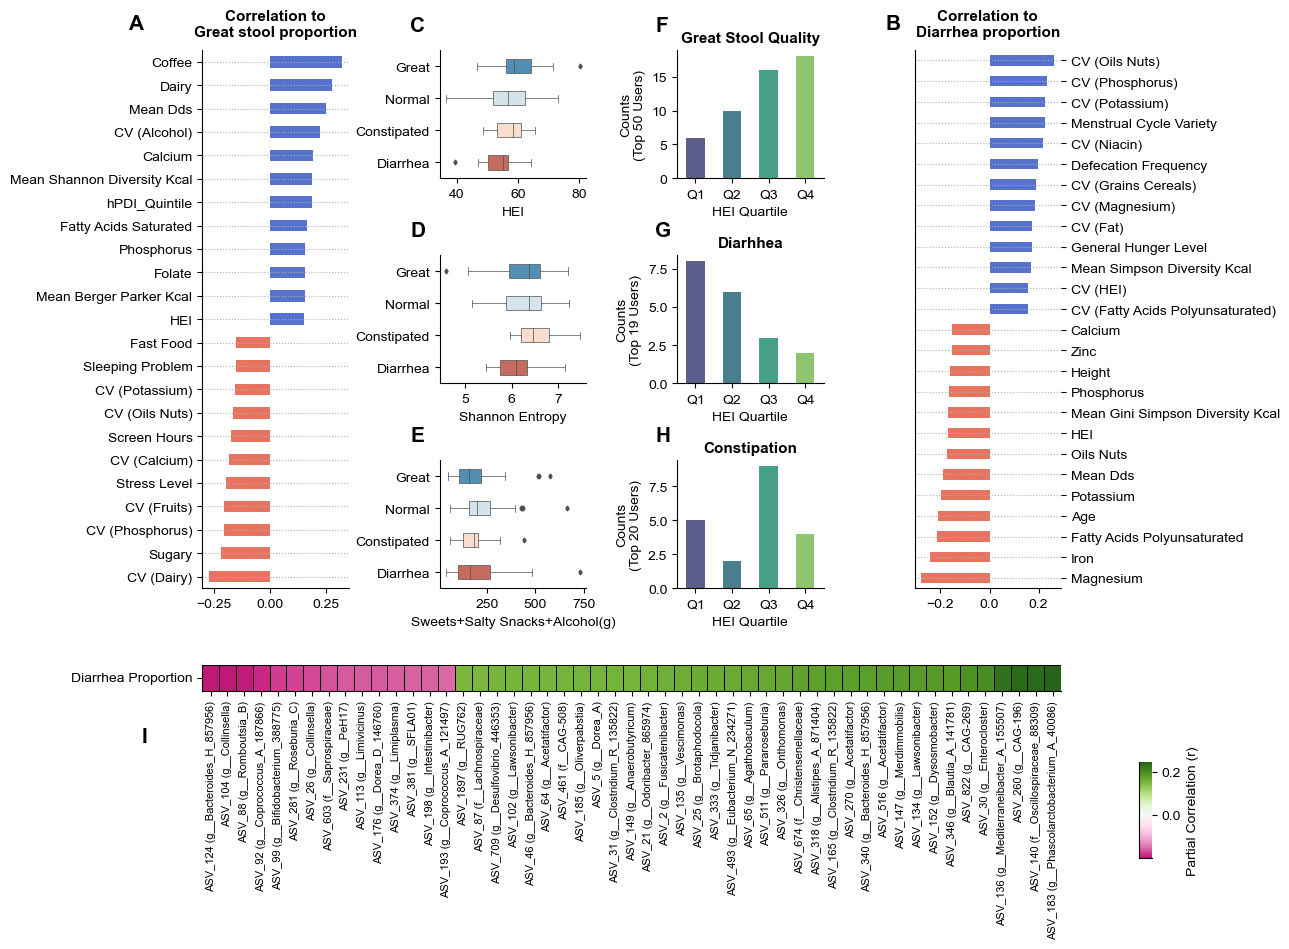

In [13]:
fig = plt.figure(figsize=(13, 9.6))
gs = GridSpec(
    7,
    4,
    figure=fig,
)  # wspace=0.4, hspace=6)

# 1st column, 1st plot (top half)
ax1 = fig.add_subplot(gs[0:2, 1])
# 1st column, 2nd plot (bottom half)
ax2 = fig.add_subplot(gs[2:4, 1])

ax2_3 = fig.add_subplot(gs[4:6, 1])

# 2nd column, 1st plot (top third)
ax3 = fig.add_subplot(gs[0:2, 2])
# 2nd column, 2nd plot (middle third)
ax4 = fig.add_subplot(gs[2:4, 2])
# 2nd column, 3rd plot (bottom third)
ax5 = fig.add_subplot(gs[4:6, 2])

# 3rd column, full height plot
ax6 = fig.add_subplot(gs[:6, 0])

# 4th column, full height plot
ax7 = fig.add_subplot(gs[:6, 3])

ax8 = fig.add_subplot(gs[6:, :])

boxplot_palette = "RdBu_r"
# Plot something on each of the axes to visualize them
sns.boxplot(
    stool_quality_meta,
    y="stool_quality",
    x="HEI",
    palette=boxplot_palette,
    width=0.45,
    fliersize=2.5,
    linewidth=0.5,
    ax=ax1,
)
ax1.set_ylabel("")
sns.boxplot(
    stool_quality_meta,
    y="stool_quality",
    x="shannon_entropy",
    palette=boxplot_palette,
    width=0.45,
    fliersize=2.5,
    linewidth=0.5,
    ax=ax2,
)
# ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90, ha='right')
ax2.set_ylabel("")
ax2.set_xlabel("Shannon Entropy")
sns.boxplot(
    stool_quality_meta,
    y="stool_quality",
    x="sweets_salty_snacks_alcohol",
    palette=boxplot_palette,
    width=0.45,
    fliersize=2.5,
    linewidth=0.5,
    ax=ax2_3,
)
# ax2_3.set_xticklabels(ax2_3.get_xticklabels(), rotation=90, ha='right')
ax2_3.set_ylabel("")
ax2_3.set_xlabel("Sweets+Salty Snacks+Alcohol(g)")

sns.barplot(
    data=q_great_quartile_counts,
    x="HEI_Quartile",
    y="Count",
    palette="viridis",
    alpha=0.9,
    width=0.5,
    ax=ax3,
)
ax3.set_ylabel(f"Counts\n(Top {q_great_quartile_counts['Count'].sum()} Users)")
ax3.set_xlabel("HEI Quartile")
ax3.set_title("Great Stool Quality", fontsize=11, fontweight="bold")

sns.barplot(
    data=q_diarrhea_quartile_counts,
    x="HEI_Quartile",
    y="Count",
    palette="viridis",
    alpha=0.9,
    width=0.5,
    ax=ax4,
)
ax4.set_ylabel(f"Counts\n(Top {q_diarrhea_quartile_counts['Count'].sum()} Users)")
ax4.set_xlabel("HEI Quartile")
ax4.set_title("Diarhhea", fontsize=11, fontweight="bold")

sns.barplot(
    data=q_constipated_quartile_counts,
    x="HEI_Quartile",
    y="Count",
    palette="viridis",
    alpha=0.9,
    width=0.5,
    ax=ax5,
)
ax5.set_ylabel(f"Counts\n(Top {q_constipated_quartile_counts['Count'].sum()} Users)")
ax5.set_xlabel("HEI Quartile")
ax5.set_title("Constipation", fontsize=11, fontweight="bold")


pos_neg_palette = {"Positive": "royalblue", "Negative": "tomato"}
sns.barplot(
    data=sqm,
    x="Correlation to great_stool_quality_proportion",
    y="Feature",
    hue="color",
    palette=pos_neg_palette,  # {'positive': 'tomato', 'negative': 'royalblue'},
    ax=ax6,
    dodge=False,
    width=0.5,
)
ax6.set_ylabel("")
ax6.set_xlabel(
    "Correlation to\nGreat stool proportion",
    fontsize=11,
    fontweight="bold",
    labelpad=10,
)
ax6.legend_.remove()
# ax6.yaxis.tick_right()
ax6.grid(axis="y", linestyle="dotted")
# Move x-axis to the top
ax6.xaxis.set_label_position("top")
# ax6.xaxis.tick_top()
ax6.spines["bottom"].set_visible(False)
ax6.spines["right"].set_visible(False)

sns.barplot(
    data=dqm,
    x="Correlation to diarrhea_proportion",
    y="Feature",
    hue="color",
    palette=pos_neg_palette,  # {'positive': 'tomato', 'negative': 'royalblue'},
    ax=ax7,
    dodge=False,
    width=0.5,
)
ax7.set_ylabel("")
ax7.set_xlabel(
    "Correlation to\nDiarrhea proportion", fontsize=11, fontweight="bold", labelpad=10
)
ax7.legend_.remove()
ax7.yaxis.tick_right()
ax7.grid(axis="y", linestyle="dotted")
ax7.xaxis.set_label_position("top")
# ax7.xaxis.tick_top()
ax7.spines["bottom"].set_visible(False)
ax7.spines["left"].set_visible(False)
################################################################################################

# pos = ax8.get_position()
# new_pos = [pos.x0 - 0.1, pos.y0, pos.width + 0.2, pos.height]  # Adjust left and right
# ax8.set_position(new_pos)

cbar_ax = fig.add_axes([0.88, 0.1, 0.01, 0.1])  # [left, bottom, width, height]
# Create the heatmap
sns.heatmap(
    parcorr_microbe_to_diarrhea.set_index("short_name")[["Diarrhea Proportion"]].T,
    cmap="PiYG",
    annot=False,
    fmt=".2f",
    ax=ax8,
    linewidths=0.5,
    linecolor="black",
    center=0,
    cbar_ax=cbar_ax,
    cbar_kws={"label": "Partial Correlation (r)"},
)
ax8.set_ylabel("")
ax8.set_xlabel("")
# Adjust x tick labels font size
ax8.set_xticklabels(ax8.get_xticklabels(), fontsize=8)
ax8.set_yticklabels(ax8.get_yticklabels(), rotation=0, va="center", ha="right")

ax8.margins(x=1)
################################################################################################

plt.tight_layout(w_pad=0.5, h_pad=1.3)
# sns.despine(top=True, right=False, left=True)

## label the panels
ax6.text(
    -0.5,
    1.04,
    "A",
    fontsize=15,
    fontweight="bold",
    fontfamily="Arial",
    transform=ax6.transAxes,
)
ax7.text(
    -0.2,
    1.04,
    "B",
    fontsize=15,
    fontweight="bold",
    fontfamily="Arial",
    transform=ax7.transAxes,
)

ax1.text(
    -0.2,
    1.15,
    "C",
    fontsize=15,
    fontweight="bold",
    fontfamily="Arial",
    transform=ax1.transAxes,
)
ax2.text(
    -0.2,
    1.15,
    "D",
    fontsize=15,
    fontweight="bold",
    fontfamily="Arial",
    transform=ax2.transAxes,
)
ax2_3.text(
    -0.2,
    1.15,
    "E",
    fontsize=15,
    fontweight="bold",
    fontfamily="Arial",
    transform=ax2_3.transAxes,
)

ax3.text(
    -0.15,
    1.15,
    "F",
    fontsize=15,
    fontweight="bold",
    fontfamily="Arial",
    transform=ax3.transAxes,
)
ax4.text(
    -0.15,
    1.15,
    "G",
    fontsize=15,
    fontweight="bold",
    fontfamily="Arial",
    transform=ax4.transAxes,
)
ax5.text(
    -0.15,
    1.15,
    "H",
    fontsize=15,
    fontweight="bold",
    fontfamily="Arial",
    transform=ax5.transAxes,
)

ax8.text(
    -0.07,
    -2,
    "I",
    fontsize=15,
    fontweight="bold",
    fontfamily="Arial",
    transform=ax8.transAxes,
)

sns.despine()


## Save the figure
plt.savefig(
    "../../figures/stool_quality_analysis/Figure_5.png", dpi=300, bbox_inches="tight"
)

plt.show()